<a href="https://colab.research.google.com/github/Jmian1520/Stroke-Prediction/blob/main/Stroke%20Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

In [ ]:
#Read CSV file
df = pd.read_csv("healthcare-dataset-stroke-data.csv")

# Display the dataset first 5 rows
print("First 5 rows of the dataset:")
df.head()

First 5 rows of the dataset:


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [ ]:
#Display the data basic information & statistic
print("Dataset Information:")
df.info()

print("\nBasic Statistics (Before Cleaning):")
df.describe(include='all')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB

Basic Statistics (Before Cleaning):


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
count,5110.000000,5110,5110.000000,5110.000000,5110.000000,5110,5110,5110,5110.000000,4909.000000,5110,5110.000000
unique,NaN,3,NaN,NaN,NaN,2,5,2,NaN,NaN,4,NaN
top,NaN,Female,NaN,NaN,NaN,Yes,Private,Urban,NaN,NaN,never smoked,NaN
freq,NaN,2994,NaN,NaN,NaN,3353,2925,2596,NaN,NaN,1892,NaN
mean,36517.829354,NaN,43.226614,0.097456,0.054012,NaN,NaN,NaN,106.147677,28.893237,NaN,0.048728
std,21161.721625,NaN,22.612647,0.296607,0.226063,NaN,NaN,NaN,45.283560,7.854067,NaN,0.215320
min,67.000000,NaN,0.080000,0.000000,0.000000,NaN,NaN,NaN,55.120000,10.300000,NaN,0.000000
25%,17741.250000,NaN,25.000000,0.000000,0.000000,NaN,NaN,NaN,77.245000,23.500000,NaN,0.000000
50%,36932.000000,NaN,45.000000,0.000000,0.000000,NaN,NaN,NaN,91.885000,28.100000,NaN,0.000000
75%,54682.000000,NaN,61.000000,0.000000,0.000000,NaN,NaN,NaN,114.090000,33.100000,NaN,0.000000


In [ ]:
# Checking Missing values
print("Missing values:")
df.isnull().sum()

Missing values:


,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,201


In [ ]:
# Replace missing value
df['bmi'] = df['bmi'].fillna(df['bmi'].median())

#check missing value again
print("Missing values(after cleaning):")
df.isnull().sum()

Missing values(after cleaning):


,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,0


In [ ]:
# Check for duplicate row
print("Duplicate Row:")
print(df.duplicated().sum())

# Check for duplicates based on unique identifier
print("\nDuplicate id:")
print(df['id'].duplicated().sum())

Duplicate Row:
0

Duplicate id:
0


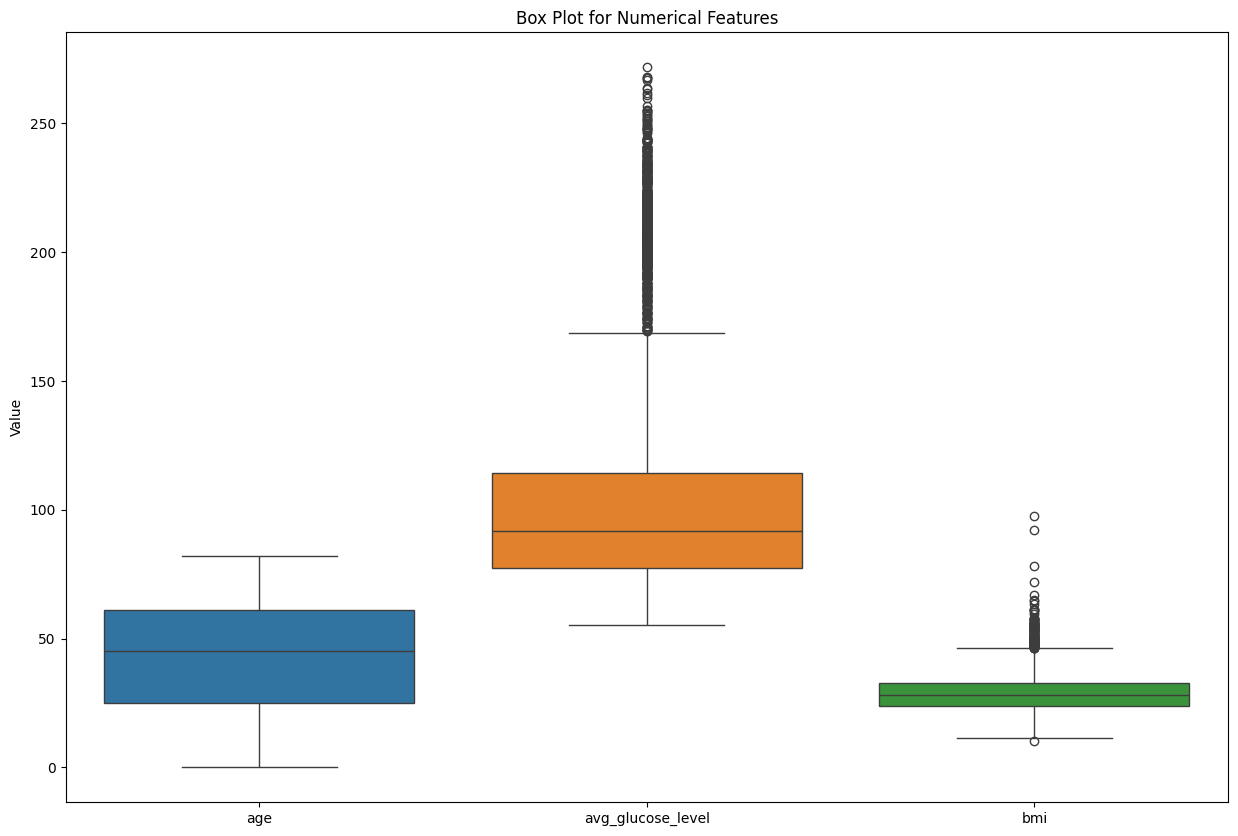

In [ ]:
#Handle Outlier
num_cols = ['age', 'avg_glucose_level', 'bmi']

# Apply box plot
plt.figure(figsize=(15, 10))
sns.boxplot(data=df[num_cols])
plt.title('Box Plot for Numerical Features')
plt.ylabel('Value')
plt.show()

**EDA**

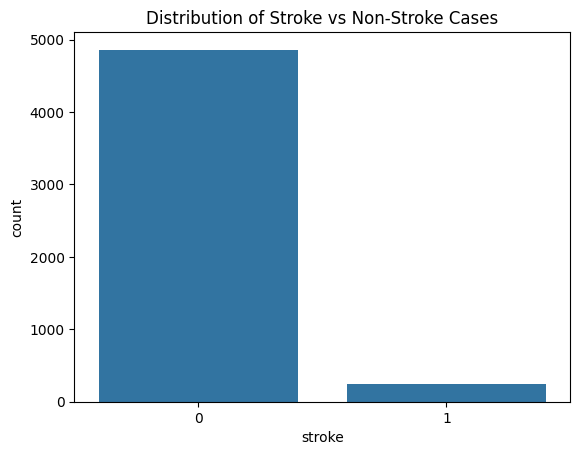

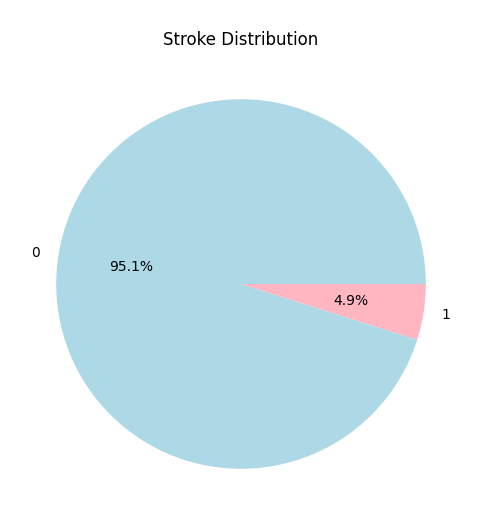

In [ ]:
#Distribution of target variable
#Countplot
sns.countplot(x='stroke', data=df)
plt.title('Distribution of Stroke vs Non-Stroke Cases')

#Apply pie to see precentage
plt.figure(figsize=(10, 6))
df['stroke'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['lightblue','lightpink'])
plt.title('\nStroke Distribution')
plt.ylabel('')
plt.show()

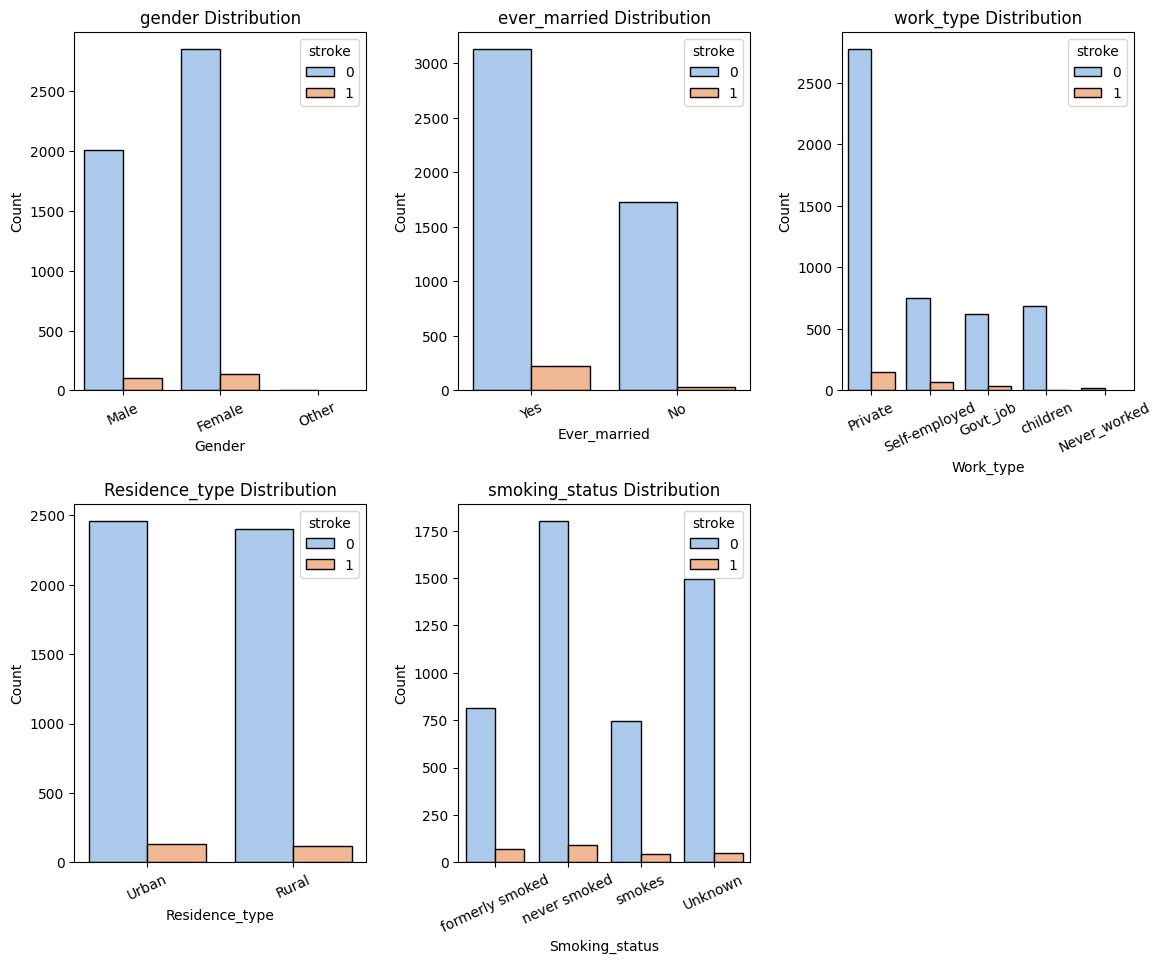

Age distribution:



<Axes: xlabel='age', ylabel='Count'>

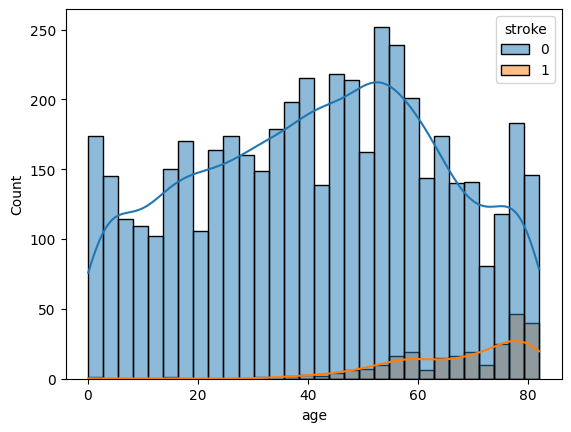

In [ ]:
# Demographic Analysis
# Demographic categorical variables
demographic_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

# Set up countplot
plt.figure(figsize=(12, 10))

for i, col in enumerate(demographic_cols, 1):
    plt.subplot(2, 3, i)
    sns.countplot(x=col, hue='stroke', data=df, palette='pastel', edgecolor='black')
    plt.title(f'{col} Distribution')
    plt.xlabel(col.capitalize())
    plt.ylabel('Count')
    plt.xticks(rotation=25)

plt.tight_layout(pad=2.0)
plt.show()

# Demographic numeric variable
print("Age distribution:\n")
sns.histplot(data=df, x='age', hue='stroke', bins=30, kde=True)

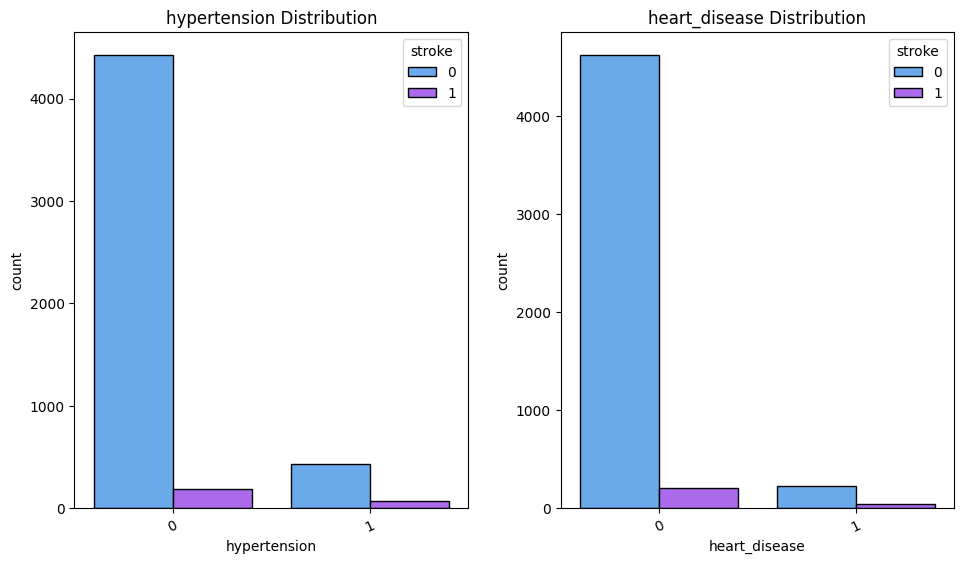

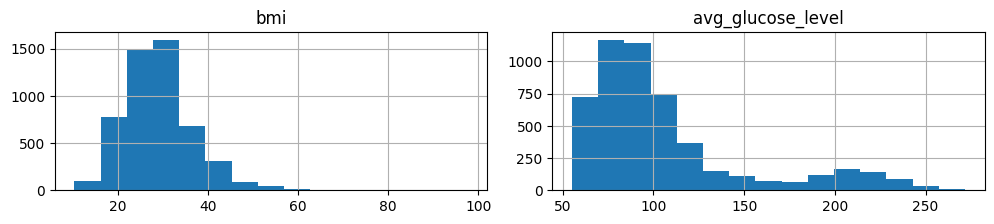

In [ ]:
# Symptoms Indicator Analysis
# Categorical variables
symp_cols = ['hypertension', 'heart_disease']

# Set up countplot
plt.figure(figsize=(10, 6))
for i, col in enumerate(symp_cols, 1):
    plt.subplot(1 ,2 , i)
    sns.countplot(x=col, hue='stroke', data=df, palette='cool', edgecolor='black')
    plt.title(f'{col} Distribution')
    plt.xticks(rotation=25)
plt.tight_layout(pad=2.0)
plt.show()

# Numeric features
num_symp_cols = ['bmi','avg_glucose_level']

# Apply histograms
df[num_symp_cols].hist(bins = 15,figsize = (15,6),layout=(3,3))
plt.tight_layout(pad=1.0)
plt.show()

Correlation analysis

In [ ]:
from scipy.stats import chi2_contingency
import pandas as pd

# Define categorical features
cat_features = ['gender', 'ever_married', 'work_type',
                'Residence_type', 'smoking_status',
                'hypertension', 'heart_disease']

chi_square_results = []

for col in cat_features:
    contingency = pd.crosstab(df[col], df['stroke'])
    chi2, p, dof, expected = chi2_contingency(contingency)
    chi_square_results.append({
        'Feature': col,
        'Chi2': round(chi2, 2),
        'p-value': round(p, 4)
    })

chi_square_df = pd.DataFrame(chi_square_results)
print(chi_square_df)


          Feature   Chi2  p-value
0          gender   0.47   0.7895
1    ever_married  58.92   0.0000
2       work_type  49.16   0.0000
3  Residence_type   1.08   0.2983
4  smoking_status  29.15   0.0000
5    hypertension  81.61   0.0000
6   heart_disease  90.26   0.0000


In [ ]:
# Point-biserial correlation
from scipy.stats import pointbiserialr

continuous_vars = ['age', 'avg_glucose_level', 'bmi']
for var in continuous_vars:
    corr, p_value = pointbiserialr(df[var], df['stroke'])
    print(f"{var}: Point-biserial correlation = {corr:.3f}, p-value = {p_value:.4f}")

age: Point-biserial correlation = 0.245, p-value = 0.0000
avg_glucose_level: Point-biserial correlation = 0.132, p-value = 0.0000
bmi: Point-biserial correlation = 0.036, p-value = 0.0098


**Encoding**

In [ ]:
# Check gender distribution
print(df['gender'].value_counts())

# Drop the single 'Other' gender record
df = df[df['gender'] != 'Other']
print("\n", df['gender'].value_counts())

gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64

 gender
Female    2994
Male      2115
Name: count, dtype: int64


In [ ]:
# Binary encoding for Gender, Residence type, even married
# manually set "Male" > 1 and "Female" > 0
gender_map = {'Male': 1, 'Female': 0}
#Apply binary encoding to gender column and drop the original data
df['Gender_Encoded'] = df['gender'].map(gender_map)
df.drop("gender", axis=1, inplace=True)

# manually set "Urban" > 1 and "Rural" > 0
residence_map = {'Urban': 1, 'Rural': 0}
#Apply binary encoding to Residence type column and drop the original data
df['Residence_type_Encoded'] = df['Residence_type'].map(residence_map)
df.drop("Residence_type", axis=1, inplace=True)

# manually set "Yes" > 1 and "No" > 0
ever_married_map = {'Yes': 1, 'No': 0}
#Apply binary encoding to even married column and drop the original data
df['ever_married_encoded'] = df['ever_married'].map(ever_married_map)
df.drop('ever_married', axis=1, inplace=True)

# Display the updated dataframe
print('After Encoded')
print(df.shape)
print(df.head())

After Encoded
(5109, 12)
      id   age  hypertension  heart_disease      work_type  avg_glucose_level  \
0   9046  67.0             0              1        Private             228.69   
1  51676  61.0             0              0  Self-employed             202.21   
2  31112  80.0             0              1        Private             105.92   
3  60182  49.0             0              0        Private             171.23   
4   1665  79.0             1              0  Self-employed             174.12   

    bmi   smoking_status  stroke  Gender_Encoded  Residence_type_Encoded  \
0  36.6  formerly smoked       1               1                       1   
1  28.1     never smoked       1               0                       0   
2  32.5     never smoked       1               1                       0   
3  34.4           smokes       1               0                       1   
4  24.0     never smoked       1               0                       0   

   ever_married_encoded  
0    

In [ ]:
# One-hot encoding for work_type
df = pd.get_dummies(df, columns=['work_type'], drop_first=True)

# Display the updated dataframe
print('After Encoded')
print(df.shape)
print(df.head())

After Encoded
(5109, 15)
      id   age  hypertension  heart_disease  avg_glucose_level   bmi  \
0   9046  67.0             0              1             228.69  36.6   
1  51676  61.0             0              0             202.21  28.1   
2  31112  80.0             0              1             105.92  32.5   
3  60182  49.0             0              0             171.23  34.4   
4   1665  79.0             1              0             174.12  24.0   

    smoking_status  stroke  Gender_Encoded  Residence_type_Encoded  \
0  formerly smoked       1               1                       1   
1     never smoked       1               0                       0   
2     never smoked       1               1                       0   
3           smokes       1               0                       1   
4     never smoked       1               0                       0   

   ever_married_encoded  work_type_Never_worked  work_type_Private  \
0                     1                   False    

In [ ]:
# Ordinal Encoding for smoking_status
from sklearn.preprocessing import OrdinalEncoder

#set the order status
smoking_status_order = [['Unknown','never smoked', 'formerly smoked', 'smokes']]
ordinal_encoder = OrdinalEncoder(categories=smoking_status_order)

#Apply ordinal encoder
df['Smoking_status_Encoded'] = ordinal_encoder.fit_transform(df[['smoking_status']])
df = df.drop('smoking_status', axis=1)

# Check the result
print('After Encoding')
print(df.shape)
print(df.head())


After Encoding
(5109, 15)
      id   age  hypertension  heart_disease  avg_glucose_level   bmi  stroke  \
0   9046  67.0             0              1             228.69  36.6       1   
1  51676  61.0             0              0             202.21  28.1       1   
2  31112  80.0             0              1             105.92  32.5       1   
3  60182  49.0             0              0             171.23  34.4       1   
4   1665  79.0             1              0             174.12  24.0       1   

   Gender_Encoded  Residence_type_Encoded  ever_married_encoded  \
0               1                       1                     1   
1               0                       0                     1   
2               1                       0                     1   
3               0                       1                     1   
4               0                       0                     1   

   work_type_Never_worked  work_type_Private  work_type_Self-employed  \
0                

In [ ]:
from sklearn.preprocessing import StandardScaler

#Initialize Standard Scaler
scaler = StandardScaler()
# Select all numerical feautures and apply standard scaler
df[['age','avg_glucose_level','bmi']] = scaler.fit_transform(df[['age','avg_glucose_level','bmi']])

# Display after standardisation
print('After Standardisation')
print(df.head())

After Standardisation
      id       age  hypertension  heart_disease  avg_glucose_level       bmi  \
0   9046  1.051242             0              1           2.706450  1.004893   
1  51676  0.785889             0              0           2.121652 -0.099142   
2  31112  1.626174             0              1          -0.004867  0.472358   
3  60182  0.255182             0              0           1.437473  0.719142   
4   1665  1.581949             1              0           1.501297 -0.631677   

   stroke  Gender_Encoded  Residence_type_Encoded  ever_married_encoded  \
0       1               1                       1                     1   
1       1               0                       0                     1   
2       1               1                       0                     1   
3       1               0                       1                     1   
4       1               0                       0                     1   

   work_type_Never_worked  work_type_Private  

In [ ]:
from sklearn.model_selection import train_test_split

# Define features and target
X = df.drop(['stroke','id'], axis=1)
y = df['stroke']

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,stratify=y,random_state=42)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (4087, 13)
Testing set size: (1022, 13)


In [ ]:
from imblearn.over_sampling import SMOTE
from collections import Counter

# Apply SMOTE to train test
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print("After SMOTE:", Counter(y_train_res))
print("Original shape:", X_train.shape)
print("New shape after SMOTE:", X_train_res.shape)

After SMOTE: Counter({0: 3888, 1: 3888})
Original shape: (4087, 13)
New shape after SMOTE: (7776, 13)


In [ ]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
log_reg.fit(X_train_res, y_train_res)
y_pred_lr = log_reg.predict(X_test)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
rf.fit(X_train_res, y_train_res)
y_pred_rf = rf.predict(X_test)


In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(random_state=42,
                    scale_pos_weight=10,
                    learning_rate=0.05,
                    max_depth=5,
                    n_estimators=200)
xgb.fit(X_train_res, y_train_res)
y_pred_xgb = xgb.predict(X_test)

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# apply gridsearchcv to logistic regression
lr_param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'class_weight': ['balanced', None]
}

lr_grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    lr_param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1,
    verbose=1
)
lr_grid.fit(X_train_res, y_train_res)


Fitting 5 folds for each of 12 candidates, totalling 60 fits


GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=1000), n_jobs=-1,
             param_grid={'C': [0.001, 0.01, 0.1, 1, 10, 100],
                         'class_weight': ['balanced', None]},
             scoring='recall', verbose=1)

In [ ]:
# apply gridsearchcv to random forest
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15],
    'min_samples_split': [2, 5],
    'class_weight': ['balanced']
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1,
    verbose=1
)
rf_grid.fit(X_train_res, y_train_res)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'class_weight': ['balanced'], 'max_depth': [10, 15],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='recall', verbose=1)

In [ ]:
# apply gridsearchcv to XGBoost optimization with medical focus
xgb_param_grid = {
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'n_estimators': [100, 200],
    'scale_pos_weight': [10, 15]
}

xgb_grid = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    xgb_param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1
)
xgb_grid.fit(X_train_res, y_train_res)

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraint...
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.05, 0.1], 'max_depth': [3, 5],
                         'n_estimators': [100, 200],
                         'scale_pos_weight': [10, 15]},
             scoring='recall')

In [ ]:
# Extract and analyze optimization results
print("Optimization Results:")
print(f"Logistic Regression Best Parameters: {lr_grid.best_params_}")
print(f"Random Forest Best Parameters: {rf_grid.best_params_}")
print(f"XGBoost Best Parameters: {xgb_grid.best_params_}")

print(f"\nLogistic Regression Best Recall: {lr_grid.best_score_:.3f}")
print(f"Random Forest Best Recall: {rf_grid.best_score_:.3f}")
print(f"XGBoost Best Recall: {xgb_grid.best_score_:.3f}")

Optimization Results:
Logistic Regression Best Parameters: {'C': 0.001, 'class_weight': 'balanced'}
Random Forest Best Parameters: {'class_weight': 'balanced', 'max_depth': 15, 'min_samples_split': 2, 'n_estimators': 100}
XGBoost Best Parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'scale_pos_weight': 15}

Logistic Regression Best Recall: 0.859
Random Forest Best Recall: 0.980
XGBoost Best Recall: 0.996


In [ ]:
# Create final models with best parameters
final_lr = lr_grid.best_estimator_
final_rf = rf_grid.best_estimator_
final_xgb = xgb_grid.best_estimator_

print("Final optimized models ready for evaluation")
print(f"Logistic Regression: {type(final_lr).__name__}")
print(f"Random Forest: {type(final_rf).__name__}")
print(f"XGBoost: {type(final_xgb).__name__}")

# Store for Section 6
optimized_models = {
    'Logistic Regression': final_lr,
    'Random Forest': final_rf,
    'XGBoost': final_xgb
}

Final optimized models ready for evaluation
Logistic Regression: LogisticRegression
Random Forest: RandomForestClassifier
XGBoost: XGBClassifier


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def evaluate_model(y_true, y_pred, y_pred_proba, model_name):
    print(f"\n{model_name} Evaluation metrics:")
    print("Accuracy:", round(accuracy_score(y_true, y_pred), 4))
    print("Precision:", round(precision_score(y_true, y_pred), 4))
    print("Recall:", round(recall_score(y_true, y_pred), 4))
    print("F1 Score:", round(f1_score(y_true, y_pred), 4))
    print("ROC-AUC (Probability):", round(roc_auc_score(y_true, y_pred_proba), 4))

# Get probability predictions for ROC-AUC
y_pred_proba_lr = final_lr.predict_proba(X_test)[:, 1]
y_pred_proba_rf = final_rf.predict_proba(X_test)[:, 1]
y_pred_proba_xgb = final_xgb.predict_proba(X_test)[:, 1]

# Get binary predictions
y_pred_lr = final_lr.predict(X_test)
y_pred_rf = final_rf.predict(X_test)
y_pred_xgb = final_xgb.predict(X_test)

# Evaluate all models with enhanced function
evaluate_model(y_test, y_pred_lr, y_pred_proba_lr, "Logistic Regression")
evaluate_model(y_test, y_pred_rf, y_pred_proba_rf, "Random Forest")
evaluate_model(y_test, y_pred_xgb, y_pred_proba_xgb, "XGBoost Classifier")


Logistic Regression Evaluation metrics:
Accuracy: 0.7162
Precision: 0.1226
Recall: 0.78
F1 Score: 0.212
ROC-AUC (Probability): 0.8345

Random Forest Evaluation metrics:
Accuracy: 0.8806
Precision: 0.1667
Recall: 0.36
F1 Score: 0.2278
ROC-AUC (Probability): 0.7823

XGBoost Classifier Evaluation metrics:
Accuracy: 0.546
Precision: 0.0876
Recall: 0.88
F1 Score: 0.1594
ROC-AUC (Probability): 0.8281



Model Performance Summary:

                     Accuracy  Precision  Recall  F1 Score  ROC-AUC
Model                                                              
Logistic Regression    0.7162     0.1226    0.78    0.2120   0.8345
Random Forest          0.8806     0.1667    0.36    0.2278   0.7823
XGBoost                0.5460     0.0876    0.88    0.1594   0.8281


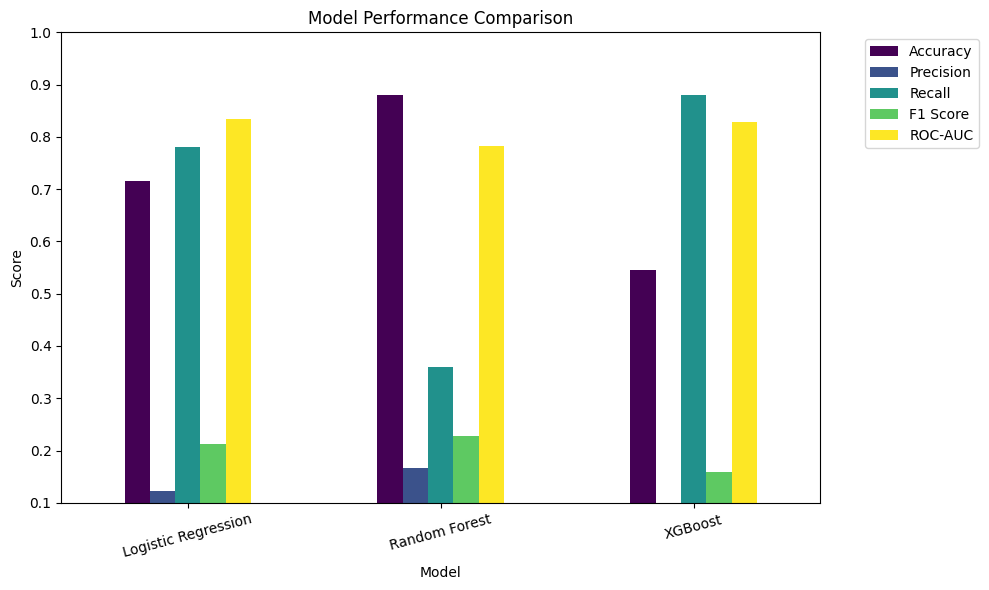

In [ ]:
results = {
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb),
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_pred_proba_lr),
        roc_auc_score(y_test, y_pred_proba_rf),
        roc_auc_score(y_test, y_pred_proba_xgb)
    ]
}

results_df = pd.DataFrame(results)
results_df.set_index("Model", inplace=True)
print("\nModel Performance Summary:\n")
print(results_df.round(4))

# Bar chart
results_df.plot(kind='bar', figsize=(10,6), colormap='viridis')
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0.1, 1.0)
plt.xticks(rotation=15)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

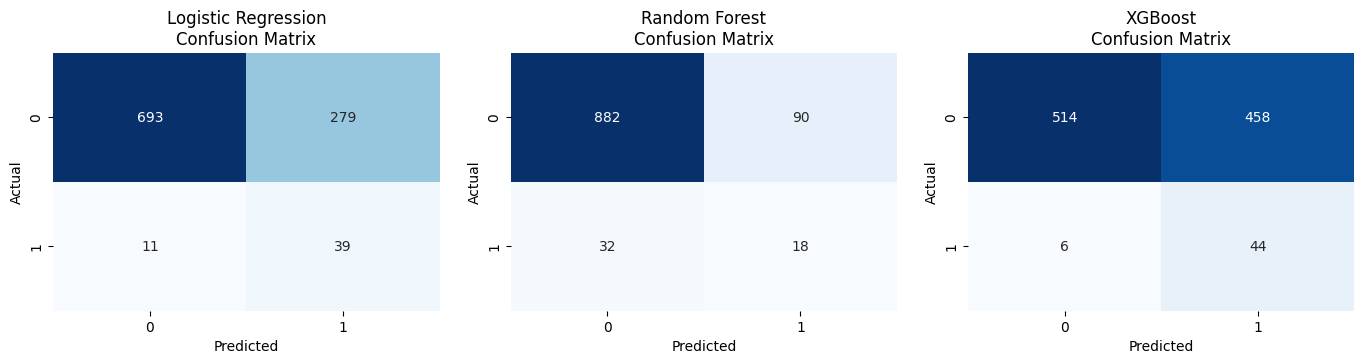

In [ ]:
from sklearn.metrics import confusion_matrix, roc_curve

models = {
    "Logistic Regression": y_pred_lr,
    "Random Forest": y_pred_rf,
    "XGBoost": y_pred_xgb
}

plt.figure(figsize=(14, 4))
for i, (name, y_pred) in enumerate(models.items(), 1):
    plt.subplot(1, 3, i)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f"{name}\nConfusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
plt.tight_layout(pad=2.0)
plt.show()

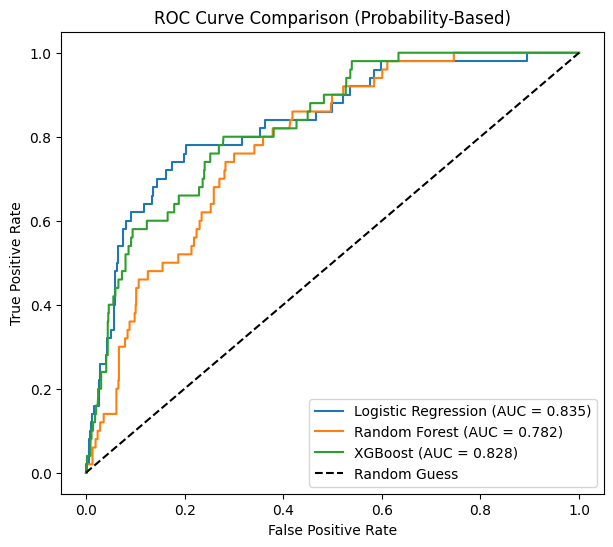

In [ ]:
plt.figure(figsize=(7, 6))
for name in models.keys():
    if name == "Logistic Regression":
        y_proba = y_pred_proba_lr
    elif name == "Random Forest":
        y_proba = y_pred_proba_rf
    else:
        y_proba = y_pred_proba_xgb

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison (Probability-Based)")
plt.legend()
plt.show()

<Figure size 1000x800 with 0 Axes>

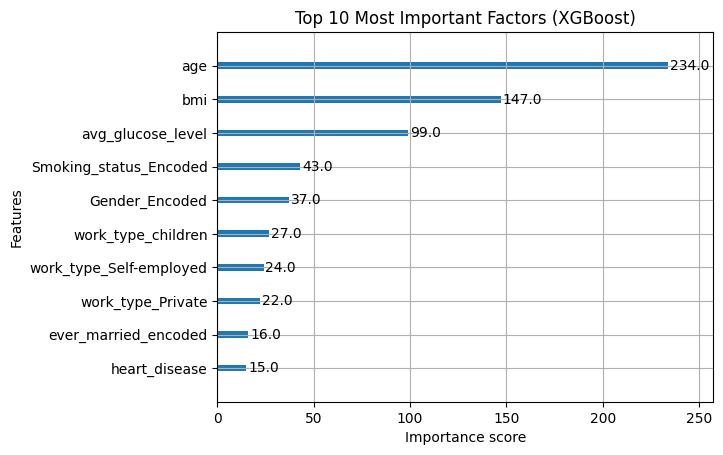

In [ ]:
from xgboost.plotting import plot_importance

plt.figure(figsize=(10,8))
plot_importance(final_xgb, max_num_features=10)
plt.title("Top 10 Most Important Factors (XGBoost)")
plt.show()